# HW 14 - Astropy
ULAB - Physics and Astronomy Division \
Due **Sunday, March 1st, 2025 at 11:59pm** on Gradescope

## 1 Unit Conversion
Import the astropy module `units` as `u` in the cell below.

In [1]:
from astropy import units as u

Convert a speed of **60 km/h** to **m/s**. \
\
Round your answer to two significant digits. *Hint: With an f-string, you can use `:.3f`, like `print(f"{speed_mps:.3f}")`*.

In [7]:
speed_kmph = 60 * u.km / u.h
speed_mps = speed_kmph.to(u.m / u.s)
print(f"{speed_kmph:.3f}")

60.000 km / h


## 2 Time Manipulation
Define **Julian Date** in the cell below.

In [ ]:
# Julian date counts the number of days since noon Universal Time in the Julian Calendar. It began January 1st, 4713 BCE.

What's the difference between the **Julian calendar** and the **Gregorian calendar**?

In [8]:
# The Gregorian Calendar created a more accurate measure of time, by adding a leap year. It began January 1st, 1 CE. It also centers around the birth of Christ in Christianity, since the creator was a Pope.

From the astropy module `time` import `Time` in the cell below.

In [9]:
from astropy.time import Time

Find the Julian Date for **the current time**. 

In [14]:
current_time = Time.now()
julian_date = current_time.jd
print(f"The Julian date for the current time is {julian_date}")

The Julian date for the current time is 2460744.669014063


Convert `1969-07-02 20:17:00` to its **Julian Date**.

In [16]:
this_random_date = Time("1969-07-02 20:17:00", scale = "utc")
julian_date_of_this_random_day = this_random_date.jd
print(f"The Julian Date of this random day is {julian_date_of_this_random_day}")

The Julian Date of this random day is 2440405.345138889


What historically happened at this date and time?

In [17]:
# The Apollo Crew landed on this moon! Also apparently the Grateful Dead played live at the Stanley Theatre...

## 3 Coordinate Transformations
From the astropy module `coordinates` import `SkyCoord`, `Galactic`, `AltAz` and `EarthLocation` in the cell below.

In [20]:
from astropy.coordinates import SkyCoord, Galactic, AltAz, EarthLocation

Define a celestial object at **RA = 15 degrees** and **DEC = -20 degrees** in ICRS. Use the astropy `Time` module.

In [22]:
celestial_object = SkyCoord(ra = 15 * u.deg, dec = -20 * u.deg, frame = "icrs")
current_time = Time.now()
print(f"Celestial Object: {celestial_object}")
print(f"The current time of the obejct is: {current_time.iso}")

Celestial Object: <SkyCoord (ICRS): (ra, dec) in deg
    (15., -20.)>
The current time of the obejct is: 2025-03-10 04:13:20.013


Convert the object's coordinates from ICSRS to **Galactic**.

In [24]:
galactic_celecstial_object = celestial_object.galactic
print(f"The object's galactic coords are l = {galactic_celecstial_object.l} and b = {galactic_celecstial_object.b}")

The object's galactic coords are l = 138.7612378253739 deg and b = -82.60718782325382 deg


Convert the object's coordinate from ICRS to **AltAz**. For AltAz frame, use the location of **Campbell Hall**.

In [33]:
most_awesome_hall = EarthLocation(lon=-122.2585 * u.deg, lat=37.8754 * u.deg, height=0 * u.m) # Lat and lon of Campbell Hall according to Google
frame_altaz = AltAz(obstime = current_time, location = most_awesome_hall)
altaz_celestial_object = celestial_object.transform_to(frame_altaz)
print(f"The altitude is {altaz_celestial_object.alt}")
print(f"Other coordinate is {altaz_celestial_object.az}")

The altitude is -14.993020544058334 deg
Other coordinate is 256.2674786821119 deg


## 4 FITS Files
From the astropy module `astropy.io` import `fits` in the cell below.

In [34]:
from astropy.io import fits

From the astropy module `astropy.utils.data` import `download_file`.

In [35]:
from astropy.utils.data import download_file

Import `numpy` in the cell below.

In [44]:
import numpy as np

Use the `download_file` astropy function to create a variable for the location of the `.fits` file from class.

In [41]:
image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)

Follow the procedure from lecture to open the `.fits` files in the cell below. Make sure to use the `hdul` format, while calling `hdul.info`, `hdul[0]` and `hdul[1]` appropriately.

In [42]:
with fits.open(image_file) as hdul:
    #hdul.info() # Displaying stuff
    data = hdul[0].data # Getting data
    header = hdul[0].header # Getting header info

With the `np.max` function, find the brightest pixel in the image. Print its value in the cell below.

In [46]:
brightest_pixel = np.max(data)
print(brightest_pixel)

22918


With the `np.min` function, find the least brightest pixel in the image. Print its value in the cell below.

In [47]:
dimmest = np.min(data)
print(dimmest)

3759


## Tables
From the astropy module `astropy.table` import `Table`.

In [51]:
from astropy.table import Table

Make an astropy table with **three** actual stars (so you will need to use google for this part). Include the `name`, `magnitude` and `spectral type`.

In [53]:
table_of_stars = Table(names = ('Name', 'Magnitude', 'SpectralType'), dtype = ('S20', 'f4', 'S10'))
table_of_stars.add_row(('Sirius', -1.46, 'A0mA1 Va'))
table_of_stars.add_row(('Canopus', -0.74, 'A9 II'))
table_of_stars.add_row(('Rigil Kentaurus', -0.27, 'G2 V'))
print(table_of_stars)

      Name      Magnitude SpectralType
--------------- --------- ------------
         Sirius     -1.46     A0mA1 Va
        Canopus     -0.74        A9 II
Rigil Kentaurus     -0.27         G2 V


Save the table as a `.fits` file. *Hint: Use the function `.write` with the argument `format='fits'`.*

In [54]:
table_of_stars.write('table_of_stars', format = 'fits')

Read and print the table in the cell below from the `.fits` file you made.

In [57]:
with fits.open('table_of_stars') as hdul:
    #hdul.info() # Displaying stuff
    data = hdul[0].data # Getting data
    header = hdul[0].header # Getting header info
print(table_of_stars)

      Name      Magnitude SpectralType
--------------- --------- ------------
         Sirius     -1.46     A0mA1 Va
        Canopus     -0.74        A9 II
Rigil Kentaurus     -0.27         G2 V


## 6 Advanced... but awesome!
With the Hipparcos catalog, construct a Hertzsprung-Russell (H-R) diagram. Overall you will do the following:
* Download and clean the stellar data from the Hipparcos catalog.
* Calculate the absolute magnitude of the stars.
* Convert and classify spectral types.
* Plot an H-R diagram using both spectral class and color-index (B-V).

In the cell below, define what an **H-R** diagram is.

In [ ]:
# An H-R diagram is a scatter plot that shows the luminosity vs. temperature of stars. It helps us understand the life and death of stars.

### 6.1 Download and Load in the Hipparcos Catalog
The catalog you are downloading contains accurate parallax measurements which will help us determine the **absolute magnitude** of stars. 
* **Absolute mangitude** = the actual brightness of a star
* **Apparent magnitude** = how bright the star appears to us on Earth

Import `pandas` in the cell below.

In [86]:
import pandas as pd

In the cell below import the file `cluster_data.csv` as a pandas dataframe. Add the following arguments:
* skiprows=44
* sep=';'
* header=None
* index_col=0
* names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']
* skipfooter=1
* engine='python'

In [87]:
cluster_data = pd.read_csv('/Users/oliviawagner/ulab/ulab_olivia/homework14/cluster_data.tsv', skiprows=44, sep=';', header=None, index_col=0, names=['HIP', 'Vmag', 'Plx', 'B-V', 'SpType'], skipfooter=1, engine='python')

Display the first few rows of the data.

In [94]:
print(cluster_data.head())

      Vmag      Plx     B-V SpType
HIP                               
10    8.59    10.76   0.489    F6V
11    7.34     4.29   0.081     A2
12    8.43     4.06   1.484  K4III
13    8.80     3.49   1.128  K0III
14    7.25     5.11   1.200     K0


### 6.2 Clean the Data
Some of the rows in the data contain **missing** or **invalid** values so we need to "clean" our data. We will start by replacing the **blank spaces with NaN**, run the cell below.

In [95]:
df_clean = df.apply(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)

Drop the rows with missing (NaN) values. *Hint: Use the `.dropna()` function`.

In [96]:
df.dropna(inplace=True)

Run the cell below. We are converting the datatypes in the columns to floats.

In [101]:
df_clean[['Vmag', 'Plx', 'B-V']] = df_clean[['Vmag', 'Plx', 'B-V']].astype(float)

# Display dataset summary
print(df_clean.describe())

                Vmag            Plx            B-V
count  114463.000000  114463.000000  114463.000000
mean        8.297699       7.104872       0.702415
std         1.248614      11.064009       0.490235
min        -1.440000     -35.100000      -0.400000
25%         7.610000       2.520000       0.341000
50%         8.400000       4.580000       0.605000
75%         9.070000       8.260000       1.075000
max        13.610000     772.330000       5.460000


### 6.3 Compute Absolute Magnitude
The absolute magnitude ($M_V$) of a star is given by:

$$
M_V = V_{\text{mag}} + 5 \cdot \log_{10}\left(\frac{\text{Plx}}{100}\right)
$$

Run the cell below.

In [102]:
df_clean['M_V'] = df_clean['Vmag'] + 5 * np.log10(df_clean['Plx'] / 100)
print(df_clean[['Vmag', 'Plx', 'M_V']].head())

     Vmag    Plx       M_V
HIP                       
10   8.59  10.76  3.749061
11   7.34   4.29  0.502286
12   8.43   4.06  1.472630
13   8.80   3.49  1.514127
14   7.25   5.11  0.792105


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Describe what the cell above is doing. 

In [104]:
# I keep getting error messages (for this entire section), but I think that the cell is returning the absolute magnitude of the cleaned data (ie the ones that are not missing or invalid).

### 6.4 Process the Spectral Types
Stars are defined by their spectral types:
* The first letter (O, B, A, F, G, K, M) indicates the **temperature** of a star.
* The digit (0-9) refines the **classification**.

Now we will extract the first two characters for sorting purposes. Run the cell below.

In [105]:
# Extract the first two characters (e.g., 'G2', 'K3')
df_clean['SpType2'] = df_clean['SpType'].str[:2]

# Keep only valid spectral classes
df_clean = df_clean[df_clean['SpType2'].str.match(r'^[OBAFGKM][0-9]')]

# Display unique spectral types
print(df_clean['SpType2'].unique())

['F6' 'A2' 'K4' 'K0' 'K2' 'F3' 'K5' 'G5' 'G0' 'G8' 'F2' 'G3' 'F7' 'A0'
 'B8' 'F0' 'G6' 'G9' 'K1' 'K3' 'F5' 'G1' 'A4' 'G2' 'B5' 'B9' 'M0' 'F8'
 'M1' 'G7' 'M2' 'B0' 'B7' 'A9' 'M3' 'A3' 'O7' 'A1' 'B4' 'A6' 'B3' 'B2'
 'A5' 'M4' 'A7' 'O8' 'M5' 'G4' 'K7' 'B1' 'O6' 'M6' 'F4' 'A8' 'K8' 'M7'
 'B6' 'O9' 'F9' 'M8' 'M9' 'K9' 'O5' 'F1' 'K6' 'O4']


What letter represents the **hottest** stars? What letter represents the **coldest** stars?

In [106]:
# The hottest stars are the ones that appear blue, which is O and B type stars. The coldest stars are red stars. The color is decieving since normally hot is red and cold is blue.

### 6.5 Plot the H-R Diagram(s)
Conver the spectral types into sortable numerical categories. Run the cell below.

In [108]:
order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df_clean['SpType2_numeric'] = df_clean['SpType2'].apply(lambda x: order[x[0]]*10 + int(x[1]))

Import `matplotlib.pyplot` in the cell below.

In [111]:
import matplotlib.pyplot as plt

**Spectral Type vs. Absolute Magnitude** \
Scatter the `df_clean['SpType2_numeric']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(0, 70).
* Set a `ylim` of `(15, -10).
* Call `xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])`.
* Call `xticks(range(5,75,10))`.
* Title the x-axis `'Spectral Type'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

AttributeError: module 'matplotlib.pyplot' has no attribute 'xticklabels'

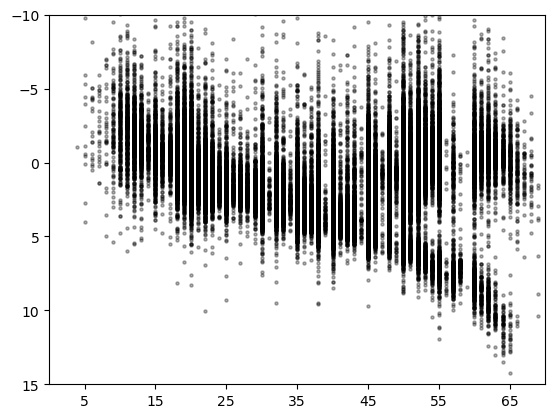

In [114]:
plt.scatter(df_clean['SpType2_numeric'], df_clean['M_V'], s=5, alpha=0.3, c='k')
plt.xlim(0,70)
plt.ylim(15,-10)
plt.xticks(range(5,75,10))
plt.xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])
plt.xlabel('Spectral Type')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Hipparcos catalog)')
plt.show()

**Color Index (B-V) vs. Absolute Magnitude** \
Scatter the `df_clean['B-V']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(-0.5, 2.5).
* Set a `ylim` of `(15, -10).
* Title the x-axis `'Color Index (B-V)'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

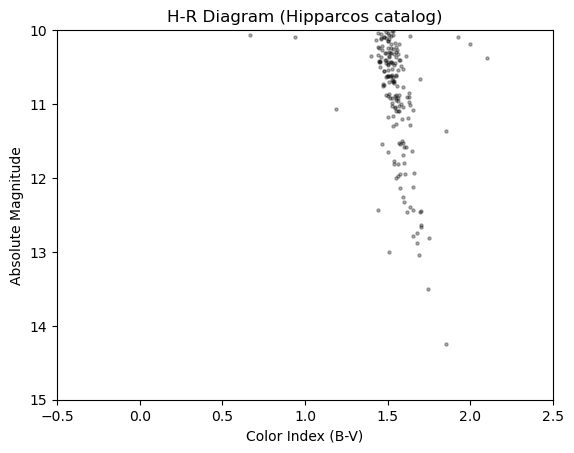

In [116]:
plt.scatter(df_clean['B-V'], df_clean['M_V'], s=5, alpha=0.3, c='k')
plt.xlim(-0.5, 2.5)
plt.ylim(15,10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram (Hipparcos catalog)')
plt.show()

### 6.6 Highlight Luminosity Classes
Great! Finally, we want to difference between our three main luminosity classes:
* Main Sequence (V), aka what our sun is
* Giants (III)
* Supergiants(I)

Run the cell below.

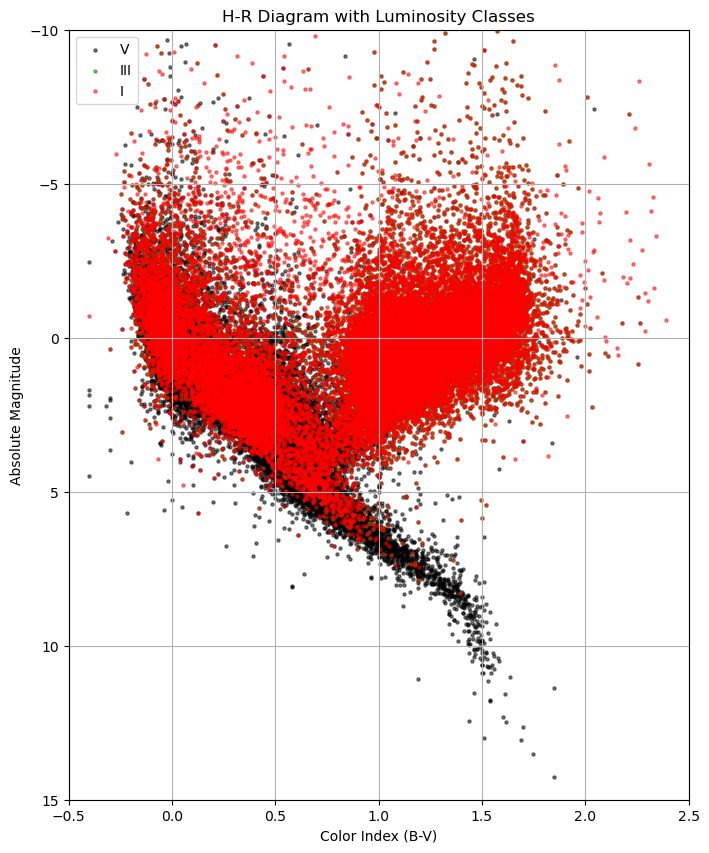

In [117]:
def plot_luminosity_class(df, label, color):
    mask = df['SpType'].str.contains(label, na=False)
    plt.scatter(df[mask]['B-V'], df[mask]['M_V'], s=5, label=label, c=color, alpha=0.5)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

plt.legend()
plt.show()


With the example above, now plot the following types **WITH** and then **WITHOUT** the ones above:
* Subdwarfs (VI)
* White dwarfs (VII)
* Subgiants (IV)
* Bright giants (II)

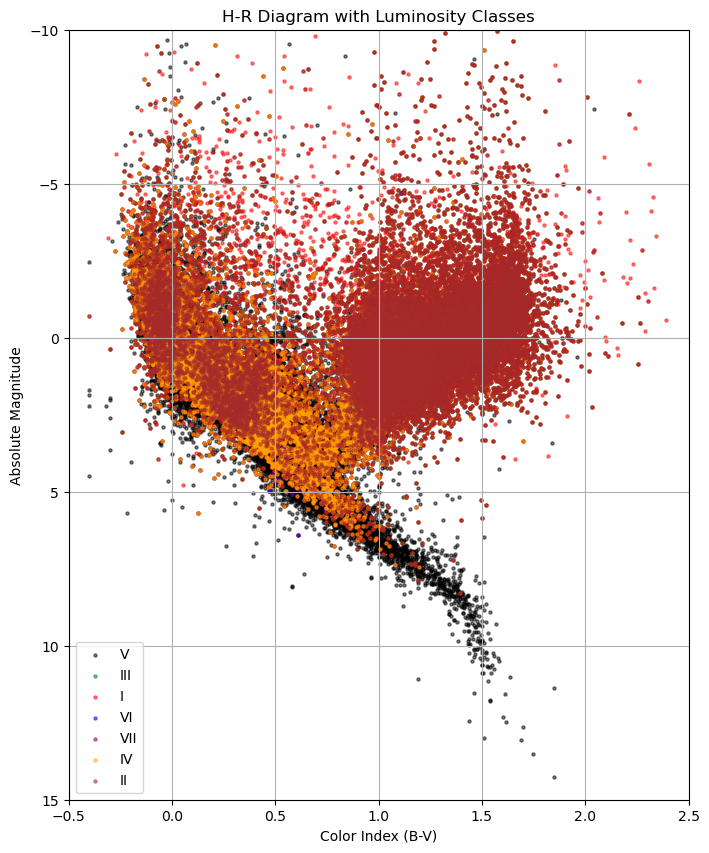

In [120]:
def plot_luminosity_class(df, label, color):
    mask = df['SpType'].str.contains(label, na=False)
    plt.scatter(df[mask]['B-V'], df[mask]['M_V'], s=5, label=label, c=color, alpha=0.5)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants
plot_luminosity_class(df_clean, 'VI', 'blue')  # Subdwarfs
plot_luminosity_class(df_clean, 'VII', 'purple')  # White dwarfs
plot_luminosity_class(df_clean, 'IV', 'orange')  # Subgiants
plot_luminosity_class(df_clean, 'II', 'brown')  # Bright giants


plt.legend()
plt.show()

Submit your FITS file and this notebook to Gradescope!